# 1. Setup and Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools, time, warnings
warnings.filterwarnings('ignore')
import matplotlib.dates as mdates


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('TF:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))


TF: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import requests

# 2. Load Raw

In [ ]:
memr = pd.read_excel("/content/Fifteen_minutes_merged_2020-2022.xlsx")
irr = pd.read_excel("/content/Fifteen_minutes_irradiance_dataset_2020-2022.xlsx")


print(memr.columns)
print(irr.columns)

Index(['datetime', 'irr_sensor_1', 'irr_sensor_2', 'irr_sensor_3',
       'irr_sensor_4', 'irr_sensor_5', 'irr_sensor_6', 'irradiation_tilted',
       'power_analyzer', 'generated_yield', 'avg_module_temp',
       'irradiance_avg', 'source_file'],
      dtype='object')
Index(['datetime', 'irr_sensor_1', 'irr_sensor_2', 'irr_sensor_3',
       'irr_sensor_4', 'irr_sensor_5', 'irr_sensor_6', 'irradiance_avg',
       'source_file'],
      dtype='object')


## Convert Datetime Columns

In [ ]:
memr['datetime'] = pd.to_datetime(memr['datetime'])
irr['datetime'] = pd.to_datetime(irr['datetime'])

## Drop Duplicate Irradiance Column from MEMR

In [ ]:
memr = memr.drop(columns=['irradiance_avg'])

## Merge MEMR with Irradiance Dataset

In [ ]:
merged = memr.merge(
    irr[['datetime', 'irradiance_avg']],
    on='datetime',
    how='left'
)

# 3. Fetch Weather Data from Open-Meteo API

In [ ]:
# Azraq PV Plant longtitude and latitude
lat = 31.876173918046508
lon = 36.771904044179706

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": lat,
    "longitude": lon,
    "start_date": "2020-01-01",
    "end_date": "2021-12-31",
    "hourly": "temperature_2m,wind_speed_10m",
    "timezone": "auto"
}

response = requests.get(url, params=params)
data = response.json()

 ## Build Weather DataFrame

In [ ]:
weather = pd.DataFrame({
    "datetime": data["hourly"]["time"],
    "temp_2m": data["hourly"]["temperature_2m"],
    "wind_speed": data["hourly"]["wind_speed_10m"]
})

weather["datetime"] = pd.to_datetime(weather["datetime"])

## Preview Weather Data

In [ ]:
weather.head()

,datetime,temp_2m,wind_speed
0,2020-01-01 00:00:00,5.6,11.8
1,2020-01-01 01:00:00,4.9,12.2
2,2020-01-01 02:00:00,4.2,12.5
3,2020-01-01 03:00:00,3.6,9.0
4,2020-01-01 04:00:00,3.2,8.1


## Resample Hourly Weather to 15-Minute Intervals


In [ ]:
# Converting hourly to 15 min
weather = weather.set_index("datetime")

weather_15min = weather.resample("15min").interpolate()

weather_15min = weather_15min.reset_index()

## Merge Weather Data into Main Dataset


In [ ]:
df = merged.merge(
    weather_15min,
    on="datetime",
    how="left"
)

 ## Export Merged Dataset


In [ ]:
df.to_excel("updated_with_openmateo.xlsx", index=False)

# 4. Set Datetime as Index

In [ ]:
df = df.set_index('datetime').sort_index()
df.head(50)

,irr_sensor_1,irr_sensor_2,irr_sensor_3,irr_sensor_4,irr_sensor_5,irr_sensor_6,irradiation_tilted,power_analyzer,generated_yield,avg_module_temp,source_file,irradiance_avg,temp_2m,wind_speed
datetime,,,,,,,,,,,,,,
2020-03-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.882214,0.000000,12.422857,March 2020 Fixed.xlsx,0.000000,11.600,22.600
2020-03-01 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.042200,0.000000,11.410667,March 2020 Fixed.xlsx,0.000000,11.475,23.875
2020-03-01 00:30:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.621000,0.000000,11.336000,March 2020 Fixed.xlsx,0.000000,11.350,25.150
2020-03-01 00:45:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.347733,0.000000,11.243333,March 2020 Fixed.xlsx,0.000000,11.225,26.425
2020-03-01 01:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.290000,0.000000,11.357333,March 2020 Fixed.xlsx,0.000000,11.100,27.700
2020-03-01 01:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.246733,0.000000,11.379333,March 2020 Fixed.xlsx,0.000000,10.925,28.575
2020-03-01 01:30:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.623333,0.000000,11.286000,March 2020 Fixed.xlsx,0.000000,10.750,29.450
2020-03-01 01:45:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.674533,0.000000,10.998000,March 2020 Fixed.xlsx,0.000000,10.575,30.325
2020-03-01 02:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.956800,0.000000,11.344667,March 2020 Fixed.xlsx,0.000000,10.400,31.200


## Inspect Final Columns

In [ ]:
df.columns

Index(['irr_sensor_1', 'irr_sensor_2', 'irr_sensor_3', 'irr_sensor_4',
       'irr_sensor_5', 'irr_sensor_6', 'irradiation_tilted', 'power_analyzer',
       'generated_yield', 'avg_module_temp', 'source_file', 'irradiance_avg',
       'temp_2m', 'wind_speed'],
      dtype='object')

## Export Cleaned Dataset (2020–2022)

In [ ]:
df.to_excel("updated_temp_weather_2020-2022.xlsx", index=False)

# 5. Missing Data Inspection

In [ ]:
def show_nan_blocks(df, column):
    mask = df[column].isna()
    nan_groups = mask.astype(int).diff().fillna(0)

    starts = df.index[nan_groups == 1]
    ends   = df.index[nan_groups == -1]

    if mask.iloc[0]:
        starts = starts.insert(0, df.index[0])
    if mask.iloc[-1]:
        ends = ends.append(pd.Index([df.index[-1]]))

    print(f"\nMissing blocks for {column}:")
    for s, e in zip(starts, ends):
        print(f"{s} → {e}")

show_nan_blocks(df, 'avg_module_temp')
show_nan_blocks(df, 'irradiance_avg')
show_nan_blocks(df, 'temp_2m')
show_nan_blocks(df, 'wind_speed')


Missing blocks for avg_module_temp:
2020-03-27 00:00:00 → 2020-03-27 01:00:00
2021-03-26 23:00:00 → 2021-03-27 00:00:00
2021-05-21 22:00:00 → 2021-05-22 09:30:00
2021-07-31 00:00:00 → 2021-08-01 00:00:00

Missing blocks for irradiance_avg:
2020-03-27 00:00:00 → 2020-03-27 01:00:00
2021-03-26 23:00:00 → 2021-03-27 00:00:00
2021-05-21 15:45:00 → 2021-05-21 17:45:00
2021-05-21 21:15:00 → 2021-05-22 09:30:00

Missing blocks for temp_2m:
2021-12-31 23:15:00 → 2022-02-24 23:45:00

Missing blocks for wind_speed:
2021-12-31 23:15:00 → 2022-02-24 23:45:00


## Data Cleaning – Fill / Drop Missing Values

In [ ]:
# ========== DATA CLEANING FOR MODULE TEMPERATURE ==========

df[['temp_2m','wind_speed']] = df[['temp_2m','wind_speed']].ffill()

# Interpolate small gaps (only fill 4 consecutive missing point)
df[['avg_module_temp','irradiance_avg']] = df[['avg_module_temp','irradiance_avg']].interpolate(limit=4)

#  Drop remaining NaNs (large gaps only)
initial_count = len(df)
df = df.dropna(subset=['avg_module_temp', 'irradiance_avg'])
final_count = len(df)
dropped = initial_count - final_count

print(f"Shape: ({final_count}, {len(df.columns)})")
print(f"Range: {df.index.min()} -> {df.index.max()}")
print(f"Rows dropped due to missing avg_module_temp, avg_irradiance: {dropped} ({dropped/initial_count*100:.2f}%)")
print(f"Columns: {df.columns.tolist()[:]}")

Shape: (69487, 14)
Range: 2020-03-01 00:00:00 -> 2022-02-24 23:45:00
Rows dropped due to missing avg_module_temp, avg_irradiance: 0 (0.00%)
Columns: ['irr_sensor_1', 'irr_sensor_2', 'irr_sensor_3', 'irr_sensor_4', 'irr_sensor_5', 'irr_sensor_6', 'irradiation_tilted', 'power_analyzer', 'generated_yield', 'avg_module_temp', 'source_file', 'irradiance_avg', 'temp_2m', 'wind_speed']


## Check for Duplicate Rows

In [ ]:
print(df.duplicated().sum())

4


# 6. Feature Engineering – Cyclical Time Features

In [ ]:
# Remove duplicate timestamps
df = df[~df.index.duplicated(keep='first')]

# ========== FEATURE ENGINEERING: CYCLICAL TIME FEATURES ==========
# Temperature has strong daily and seasonal patterns
# Encode time cyclically to capture these patterns

df['hour_sin']   = np.sin(2 * np.pi * df.index.hour   / 24)
df['hour_cos']   = np.cos(2 * np.pi * df.index.hour   / 24)
df['month_sin']  = np.sin(2 * np.pi * df.index.month  / 12)
df['month_cos']  = np.cos(2 * np.pi * df.index.month  / 12)
df['minute_sin'] = np.sin(2 * np.pi * df.index.minute / 60)
df['minute_cos'] = np.cos(2 * np.pi * df.index.minute / 60)

## Define Lag Features, Final Feature Set, and Target

In [ ]:
# ========== DEFINE FEATURES & TARGET ==========
df['temp_lag1']   = df['avg_module_temp'].shift(1)   # 15 min ago
df['temp_lag4']   = df['avg_module_temp'].shift(4)   # 1 hour ago
df['temp_lag96']  = df['avg_module_temp'].shift(96)  # same time yesterday (24h)
df = df.dropna(subset=['temp_lag1', 'temp_lag4','temp_lag96','irradiance_avg', 'avg_module_temp']).copy()

FEATURE_COLS = [
    'temp_lag1', 'temp_lag4', 'temp_lag96',
    'irradiance_avg',
    'wind_speed', 'temp_2m',
    'hour_sin', 'hour_cos',
    'month_sin', 'month_cos',
    'minute_sin', 'minute_cos'
]

TARGET_COLS = ['avg_module_temp']

df = df[FEATURE_COLS + TARGET_COLS].copy()

print(f"Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Target columns ({len(TARGET_COLS)}): {TARGET_COLS}")
print(f"\nDataset shape: {df.shape}")

Feature columns (12): ['temp_lag1', 'temp_lag4', 'temp_lag96', 'irradiance_avg', 'wind_speed', 'temp_2m', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'minute_sin', 'minute_cos']
Target columns (1): ['avg_module_temp']

Dataset shape: (69364, 13)


# 7. Train / Validation / Test Split

In [ ]:
# ========== TRAIN-TEST SPLIT ==========
# Use temporal split: first 70% for training, last 30% for testing

TEST_SPLIT = 0.3
VAL_SPLIT = 0.2

X = df[FEATURE_COLS].values
y = df[TARGET_COLS].values

# First split: train vs test
split_idx = int(len(df) * (1 - TEST_SPLIT))

X_train_full = X[:split_idx]
X_test       = X[split_idx:]

y_train_full = y[:split_idx]
y_test       = y[split_idx:]


# Second split: train vs validation (from training only)
val_idx = int(len(X_train_full) * (1 - VAL_SPLIT))
X_train = X_train_full[:val_idx]
X_val   = X_train_full[val_idx:]

y_train = y_train_full[:val_idx]
y_val   = y_train_full[val_idx:]

print(f"Train set: {len(X_train):,}")
print(f"Validation set: {len(X_val):,}")
print(f"Test set: {len(X_test):,}")

Train set: 38,843
Validation set: 9,711
Test set: 20,810


# 8. Scale Features and Target (MinMax)

In [ ]:
# ========== SCALING DATA ==========
# MinMaxScaler: [0, 1] normalization for neural network training
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)

y_train_sc = scaler_y.fit_transform(y_train)
y_test_sc = scaler_y.transform(y_test)


X_val_sc = scaler_X.transform(X_val)
y_val_sc = scaler_y.transform(y_val)

# 9. Create LSTM Input Sequences

In [ ]:
# ========== SEQUENCE CREATION HELPER FUNCTION ==========
# Create sequences of length B_SEQ for LSTM training
def create_sequences(X, y, seq_length):
    X_seq, y_seq = [], []

    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i + seq_length])
    return np.array(X_seq), np.array(y_seq)


SEQ_LENGTH = 48

X_train_seq, y_train_seq = create_sequences(X_train_sc, y_train_sc, SEQ_LENGTH)
X_val_seq, y_val_seq     = create_sequences(X_val_sc, y_val_sc, SEQ_LENGTH)
X_test_seq, y_test_seq   = create_sequences(X_test_sc, y_test_sc, SEQ_LENGTH)

print(f'Sequence length: {SEQ_LENGTH} steps (12 hours of 15-min intervals)')
print(f'X_train_seq shape: {X_train_seq.shape}')
print(f'X_val_seq shape: {X_val_seq.shape}')
print(f'X_test_seq shape: {X_test_seq.shape}')

Sequence length: 48 steps (12 hours of 15-min intervals)
X_train_seq shape: (38795, 48, 12)
X_val_seq shape: (9663, 48, 12)
X_test_seq shape: (20762, 48, 12)


# 10. Build the LSTM Model

In [ ]:
def build_lstm(input_shape, units, num_layers, dropout, learning_rate):

    model = Sequential()

    model.add(LSTM(units,
                   return_sequences=(num_layers > 1),
                   input_shape=input_shape))

    if dropout > 0:
        model.add(Dropout(dropout))

    for i in range(1, num_layers):
        return_seq = (i < num_layers - 1)
        model.add(LSTM(units, return_sequences=return_seq))

        if dropout > 0:
            model.add(Dropout(dropout))

    model.add(Dense(1))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mse'
    )

    model.summary()
    return model

# 11. Train the Model

In [ ]:
# ========== TRAIN MODEL ==========

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

model = build_lstm(
    input_shape=(48, X_train_seq.shape[2]),
    units=32,
    num_layers=2,
    dropout=0.2,
    learning_rate=0.001
)

history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=100,
    batch_size=32,
    #callbacks=[early_stopping],
    verbose=1
)

print(f'\nTraining complete. Final epoch: {len(history.history["loss"])}')

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 48, 32)         │         5,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 48, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,113 (55.13 KB)

 Trainable params: 14,113 (55.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.0049 - val_loss: 0.0045
Epoch 2/100
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0019 - val_loss: 0.0042
Epoch 3/100
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0013 - val_loss: 0.0030
Epoch 4/100
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 9.9911e-04 - val_loss: 0.0022
Epoch 5/100
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 8.5633e-04 - val_loss: 0.0019
Epoch 6/100
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 7.7551e-04 - val_loss: 0.0016
Epoch 7/100
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 7.0071e-04 - val_loss: 0.0015
Epoch 8/100
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 6.8369e-04 - val_loss: 0.0013
Epoch 9/100
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 6.5720e-04 - val_loss: 0.0012
Epoch 10/100
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 6.4572e-04 - val_loss: 0.0011
Epoch 11/100
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 6.4208

# 12. Generate Predictions on the Test Set

In [ ]:
# ========== PREDICTIONS ==========

# Make predictions on test set
y_pred_scaled = model.predict(X_test_seq, verbose=0)

# Convert back to original scale
y_test_original = scaler_y.inverse_transform(y_test_seq)
y_pred_original = scaler_y.inverse_transform(y_pred_scaled)

# Flatten for metrics
y_test_flat = y_test_original.flatten()
y_pred_flat = y_pred_original.flatten()

print(f'Predictions generated for {len(y_pred_flat):,} test samples')

Predictions generated for 20,762 test samples


## Sanity Check – Prediction Shapes

In [ ]:
print("y_pred_scaled shape:", y_pred_scaled.shape)
print("scaler_y.min_.shape:", scaler_y.min_.shape)

y_pred_scaled shape: (20762, 1)
scaler_y.min_.shape: (1,)


## Sanity Check – Target Column

In [ ]:
print(df.columns)
print(df[['avg_module_temp']].shape)

Index(['temp_lag1', 'temp_lag4', 'temp_lag96', 'irradiance_avg', 'wind_speed',
       'temp_2m', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
       'minute_sin', 'minute_cos', 'avg_module_temp'],
      dtype='object')
(69364, 1)


## Evaluation Metrics on Original Scale

In [ ]:
# Metrics in normalized scale (0–1)
mae_scaled = mean_absolute_error(y_test_seq, y_pred_scaled)
rmse_scaled = np.sqrt(mean_squared_error(y_test_seq, y_pred_scaled))
r2_scaled = r2_score(y_test_seq, y_pred_scaled)

print("\nSCALED METRICS (0–1 range)")
print("===============================")
print(f"MAE:  {mae_scaled:.4f}")
print(f"RMSE: {rmse_scaled:.4f}")
print(f"R²:   {r2_scaled:.4f}")


SCALED METRICS (0–1 range)
MAE:  0.0125
RMSE: 0.0207
R²:   0.9886


In [ ]:
# ========== METRICS ==========

mae = mean_absolute_error(y_test_flat, y_pred_flat)
rmse = np.sqrt(mean_squared_error(y_test_flat, y_pred_flat))
r2 = r2_score(y_test_flat, y_pred_flat)

# Calculate bias (systematic under/over prediction)
bias = np.mean(y_test_flat - y_pred_flat)
residuals = y_test_flat - y_pred_flat
residual_std = np.std(residuals)

print('\n' + '='*60)
print('MODEL PERFORMANCE (Scaled Values)')
print('='*60)
print(f'Mean Absolute Error (MAE):     {mae:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'R² Score:                       {r2:.4f}')
print(f'Prediction Bias:                {bias:.4f}')
print(f'Residual Std Dev:               {residual_std:.4f}')
print('='*60)

# Interpretation
print(f'\nInterpretation:')
print(f'  - On average, predictions are off by {mae:.4f} (scaled units)')
print(f'  - The model explains {r2*100:.1f}% of variance')

if abs(bias) < 0.01:
    print(f'  - No systematic bias (good balance)')
elif bias > 0:
    print(f'  - Model tends to under-predict by {abs(bias):.4f}')
else:
    print(f'  - Model tends to over-predict by {abs(bias):.4f}')


MODEL PERFORMANCE (Scaled Values)
Mean Absolute Error (MAE):     0.9299
Root Mean Squared Error (RMSE): 1.5381
R² Score:                       0.9886
Prediction Bias:                0.2348
Residual Std Dev:               1.5200

Interpretation:
  - On average, predictions are off by 0.9299 (scaled units)
  - The model explains 98.9% of variance
  - Model tends to under-predict by 0.2348


## Evaluation Metrics with Temperature Units (°C)

In [ ]:
# ========== METRICS ==========

mae = mean_absolute_error(y_test_flat, y_pred_flat)
rmse = np.sqrt(mean_squared_error(y_test_flat, y_pred_flat))
r2 = r2_score(y_test_flat, y_pred_flat)

# Calculate bias (systematic under/over prediction)
bias = np.mean(y_test_flat - y_pred_flat)
residuals = y_test_flat - y_pred_flat
residual_std = np.std(residuals)

print('\n' + '='*60)
print('MODEL PERFORMANCE (Temperature Forecasting)')
print('='*60)
print(f'Mean Absolute Error (MAE):     {mae:.4f} °C')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f} °C')
print(f'R² Score:                       {r2:.4f}')
print(f'Prediction Bias:                {bias:.4f} °C')
print(f'Residual Std Dev:               {residual_std:.4f} °C')
print('='*60)

# Interpretation
print(f'\nInterpretation:')
print(f'  - On average, predictions are off by {mae:.2f}°C')
print(f'  - The model explains {r2*100:.1f}% of temperature variance')
if abs(bias) < 0.1:
    print(f'  - No systematic bias (good balance)')
elif bias > 0:
    print(f'  - Model tends to under-predict by {abs(bias):.2f}°C')
else:
    print(f'  - Model tends to over-predict by {abs(bias):.2f}°C')


MODEL PERFORMANCE (Temperature Forecasting)
Mean Absolute Error (MAE):     0.9299 °C
Root Mean Squared Error (RMSE): 1.5381 °C
R² Score:                       0.9886
Prediction Bias:                0.2348 °C
Residual Std Dev:               1.5200 °C

Interpretation:
  - On average, predictions are off by 0.93°C
  - The model explains 98.9% of temperature variance
  - Model tends to under-predict by 0.23°C


# 13. Visualization – Training Loss Curve

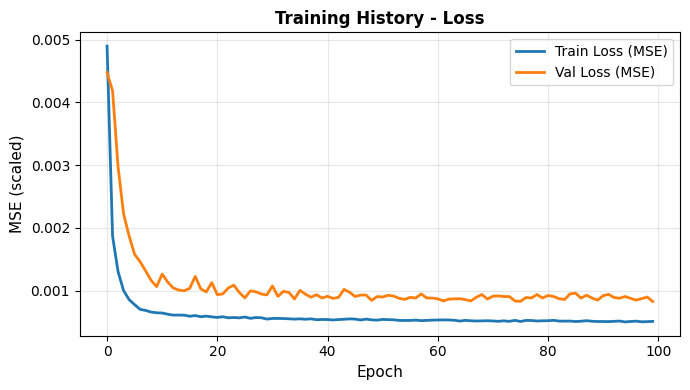

Training loss curve plotted


In [ ]:
# ========== TRAINING HISTORY ==========

plt.figure(figsize=(7, 4))

plt.plot(history.history['loss'], label='Train Loss (MSE)', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss (MSE)', linewidth=2)

plt.xlabel('Epoch', fontsize=11)
plt.ylabel('MSE (scaled)', fontsize=11)
plt.title('Training History - Loss', fontsize=12, fontweight='bold')

plt.legend(fontsize=10)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('Training loss curve plotted')

## Visualization – Predicted vs Actual

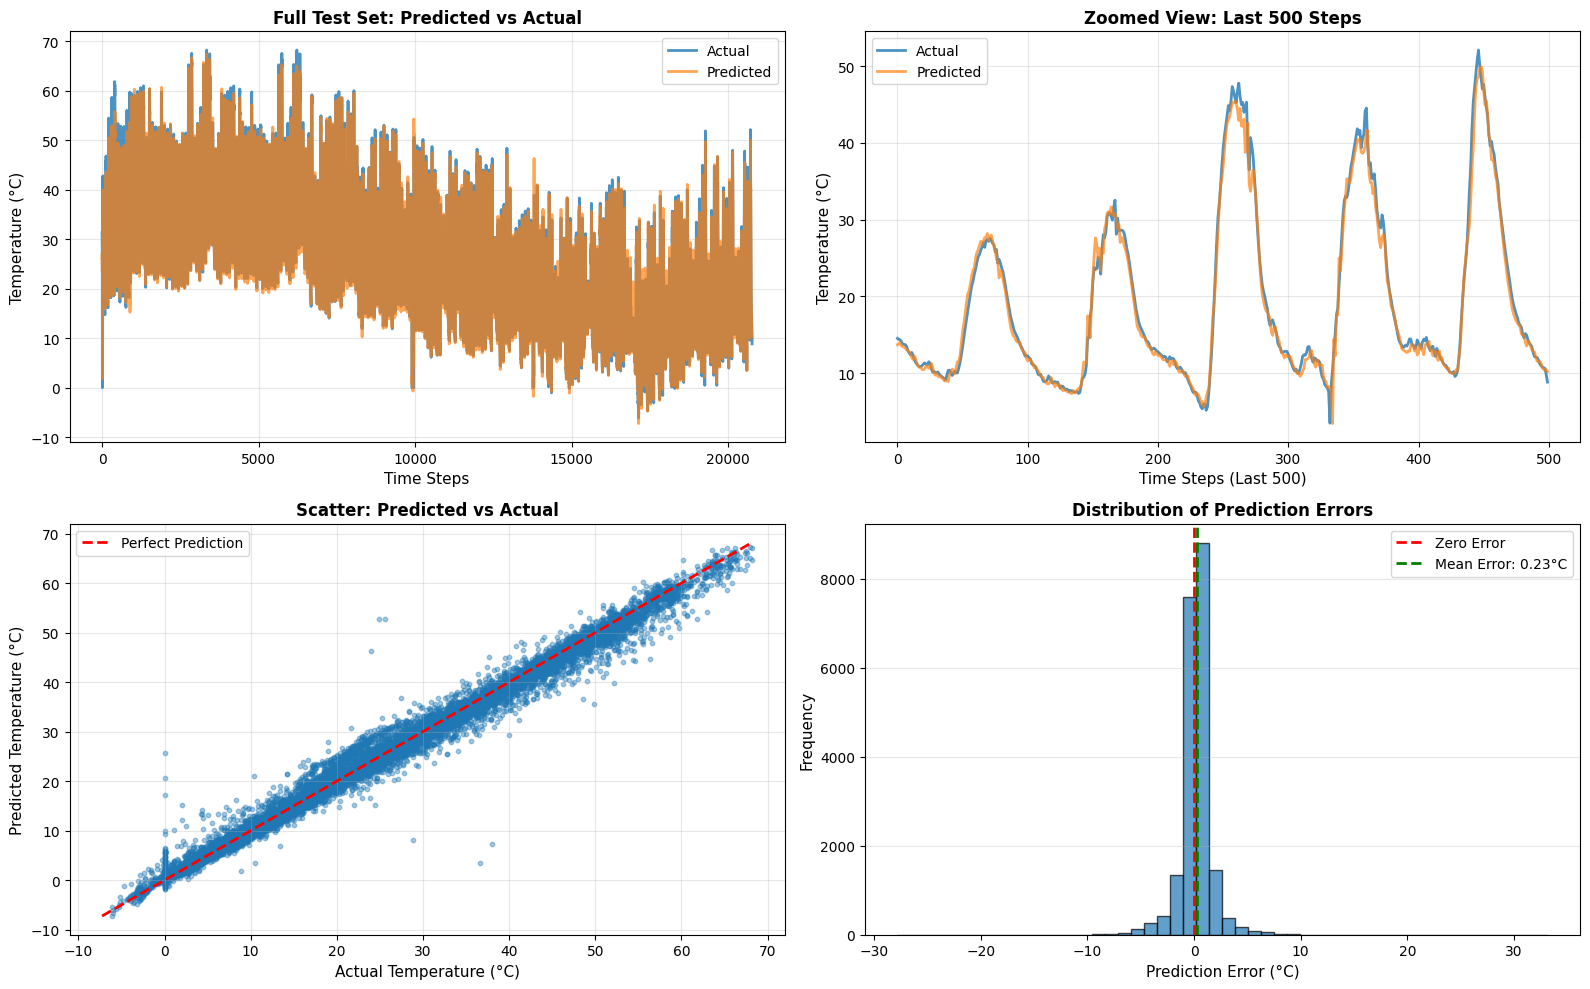

Prediction visualizations plotted


In [ ]:
# ========== PREDICTIONS VS ACTUAL ==========

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Full test set
ax = axes[0, 0]
ax.plot(y_test_flat, label='Actual', linewidth=2, alpha=0.8)
ax.plot(y_pred_flat, label='Predicted', linewidth=2, alpha=0.7)
ax.set_xlabel('Time Steps', fontsize=11)
ax.set_ylabel('Temperature (°C)', fontsize=11)
ax.set_title('Full Test Set: Predicted vs Actual', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# 2. Last 500 samples (zoomed)
ax = axes[0, 1]
ax.plot(y_test_flat[-500:], label='Actual', linewidth=2, alpha=0.8)
ax.plot(y_pred_flat[-500:], label='Predicted', linewidth=2, alpha=0.7)
ax.set_xlabel('Time Steps (Last 500)', fontsize=11)
ax.set_ylabel('Temperature (°C)', fontsize=11)
ax.set_title('Zoomed View: Last 500 Steps', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# 3. Scatter plot
ax = axes[1, 0]
ax.scatter(y_test_flat, y_pred_flat, alpha=0.4, s=10)
min_val = min(y_test_flat.min(), y_pred_flat.min())
max_val = max(y_test_flat.max(), y_pred_flat.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Temperature (°C)', fontsize=11)
ax.set_ylabel('Predicted Temperature (°C)', fontsize=11)
ax.set_title('Scatter: Predicted vs Actual', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# 4. Residuals
ax = axes[1, 1]
ax.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(0, color='r', linestyle='--', linewidth=2, label='Zero Error')
ax.axvline(bias, color='g', linestyle='--', linewidth=2, label=f'Mean Error: {bias:.2f}°C')
ax.set_xlabel('Prediction Error (°C)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Distribution of Prediction Errors', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print('Prediction visualizations plotted')

## Visualization – Error Analysis

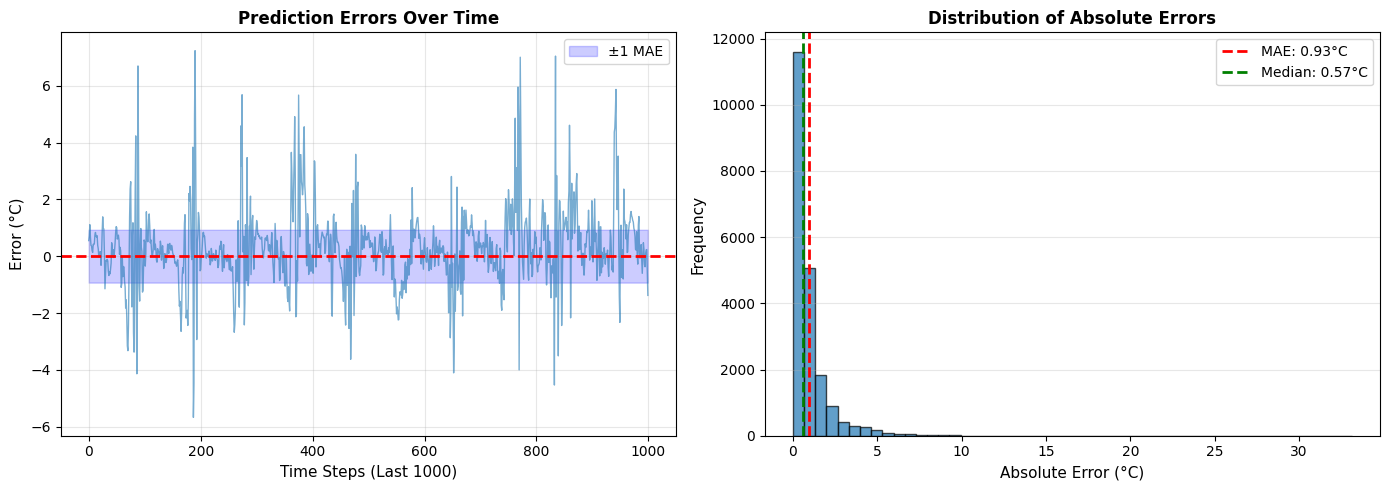

Error analysis plotted


In [ ]:
# ========== ERROR ANALYSIS ==========

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals over time
ax = axes[0]
ax.plot(residuals[-1000:], alpha=0.6, linewidth=1)
ax.axhline(0, color='r', linestyle='--', linewidth=2)
ax.fill_between(range(len(residuals[-1000:])), -mae, mae, alpha=0.2, color='blue', label=f'±1 MAE')
ax.set_xlabel('Time Steps (Last 1000)', fontsize=11)
ax.set_ylabel('Error (°C)', fontsize=11)
ax.set_title('Prediction Errors Over Time', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Absolute error distribution
ax = axes[1]
abs_errors = np.abs(residuals)
ax.hist(abs_errors, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(mae, color='r', linestyle='--', linewidth=2, label=f'MAE: {mae:.2f}°C')
ax.axvline(np.median(abs_errors), color='g', linestyle='--', linewidth=2, label=f'Median: {np.median(abs_errors):.2f}°C')
ax.set_xlabel('Absolute Error (°C)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Distribution of Absolute Errors', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print('Error analysis plotted')

# 14. Save Test-Set Predictions

In [ ]:
# ========== SAVE PREDICTIONS TO CSV ==========

# Get test datetime index (accounting for sequence length shift)
test_start_idx = split_idx + SEQ_LENGTH
test_datetime = df.index[test_start_idx:test_start_idx+len(y_pred_flat)]

results_df = pd.DataFrame({
    'datetime': test_datetime,
    'actual_temperature': y_test_flat,
    'predicted_temperature': y_pred_flat,
    'error': residuals,
    'abs_error': np.abs(residuals)
})

results_df = results_df.set_index('datetime')
results_df.to_csv('lstm_temperature_predictions_lagged_droupout02.csv')

print('✅ Predictions saved to: lstm_temperature_predictions_lagged_droupout02.csv')
print(f'\nFirst few predictions:')
print(results_df.head(10))

✅ Predictions saved to: lstm_temperature_predictions_lagged_droupout02.csv

First few predictions:
                     actual_temperature  predicted_temperature     error  \
datetime                                                                   
2021-06-13 06:45:00           21.630667              22.230434 -0.599768   
2021-06-13 07:00:00           22.806667              24.378866 -1.572200   
2021-06-13 07:15:00           24.062000              25.745649 -1.683649   
2021-06-13 07:30:00           25.244000              26.681507 -1.437507   
2021-06-13 07:45:00           26.298667              28.296846 -1.998180   
2021-06-13 08:00:00           27.582667              30.383003 -2.800337   
2021-06-13 08:15:00           29.010667              31.728741 -2.718074   
2021-06-13 08:30:00           30.258667              33.456707 -3.198040   
2021-06-13 08:45:00           31.639333              34.250992 -2.611658   
2021-06-13 09:00:00           33.138667              36.465607 -3

# 15. Save the Trained Model

In [ ]:
# ========== SAVE MODEL ==========

# Save in Keras format (recommended)
model.save('lstm_temperature_model_lagged_temp_drouput02.keras')

print('✅ Model saved to: lstm_temperature_model_lagged_temp_drouput02.keras')
print(f'\nModel summary:')
model.summary()

✅ Model saved to: lstm_temperature_model_lagged_temp_drouput02.keras

Model summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 48, 32)         │         5,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,341 (165.40 KB)

 Trainable params: 14,113 (55.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 28,228 (110.27 KB)

# 16. Load Saved Model for Unseen-Data Evaluation

In [ ]:
loaded_model = tf.keras.models.load_model('/content/lstm_temperature_model_lagged_temp_only.keras')
print('Model loaded.')

Model loaded.


# 17. Load 2022 Unseen Dataset

In [ ]:
new_df = pd.read_excel('/content/Fifteen_minutes_merged_2022_data.xlsx')

# Convert datetime and set as index
new_df['datetime'] = pd.to_datetime(new_df['datetime'])
new_df = new_df.set_index('datetime').sort_index()

## Inspect Columns of 2022 Data

In [ ]:
new_df.columns

Index(['irr_sensor_1', 'irr_sensor_2', 'irr_sensor_3', 'irr_sensor_4',
       'irr_sensor_5', 'irr_sensor_6', 'irradiation_tilted', 'power_analyzer',
       'generated_yield', 'avg_module_temp', 'irradiance_avg', 'source_file'],
      dtype='object')

## Fetch 2022 Weather Data from Open-Meteo

In [ ]:
# Azraq PV Plant longtitude and latitude
lat = 31.876173918046508
lon = 36.771904044179706

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": lat,
    "longitude": lon,
     "start_date": "2022-01-01",
    "end_date": "2022-12-31",
    "hourly": "temperature_2m,wind_speed_10m",
    "timezone": "auto"
}

response = requests.get(url, params=params)
data = response.json()

## Build 2022 Weather DataFrame

In [ ]:
weather = pd.DataFrame({
    "datetime": data["hourly"]["time"],
    "temp_2m": data["hourly"]["temperature_2m"],
    "wind_speed": data["hourly"]["wind_speed_10m"]
})

weather["datetime"] = pd.to_datetime(weather["datetime"])

## Resample 2022 Weather to 15-Min

In [ ]:
# Resample to 15 min
weather = weather.set_index("datetime")
weather = weather.resample("15min").interpolate()

## Merge Weather with 2022 Data

In [ ]:
new_df = new_df.merge(weather, left_index=True, right_index=True, how='left')

## Clean Missing Weather Values

In [ ]:
# Cleaning
new_df[['temp_2m','wind_speed']] = new_df[['temp_2m','wind_speed']].ffill()

## Feature Engineering and Prediction on 2022 Data

In [ ]:
# ========== 2022 UNSEEN DATA PREPARATION ==========
new_df['temp_lag1']  = new_df['avg_module_temp'].shift(1)
new_df['temp_lag4']  = new_df['avg_module_temp'].shift(4)
new_df['temp_lag96'] = new_df['avg_module_temp'].shift(96)

# --- Slice back to 2022 only ---

# Time features
new_df['hour_sin']   = np.sin(2 * np.pi * new_df.index.hour   / 24)
new_df['hour_cos']   = np.cos(2 * np.pi * new_df.index.hour   / 24)
new_df['month_sin']  = np.sin(2 * np.pi * new_df.index.month  / 12)
new_df['month_cos']  = np.cos(2 * np.pi * new_df.index.month  / 12)
new_df['minute_sin'] = np.sin(2 * np.pi * new_df.index.minute / 60)
new_df['minute_cos'] = np.cos(2 * np.pi * new_df.index.minute / 60)

# --- Drop any remaining NaNs and select features ---
new_df = new_df.dropna(subset=FEATURE_COLS).copy()

X_new    = new_df[FEATURE_COLS].values
y_new_true = new_df['avg_module_temp'].values

# --- Scale using TRAINING scaler only ---
X_new_sc = scaler_X.transform(X_new)

# --- Create sequences ---
X_new_seq = []
for i in range(len(X_new_sc) - SEQ_LENGTH):
    X_new_seq.append(X_new_sc[i:i + SEQ_LENGTH])
X_new_seq = np.array(X_new_seq)

# --- Predict ---
y_new_pred_sc = loaded_model.predict(X_new_seq, verbose=0)
y_new_pred    = scaler_y.inverse_transform(y_new_pred_sc)[:, 0]

# --- Align index ---
new_index  = new_df.index[SEQ_LENGTH:]
y_new_true = y_new_true[SEQ_LENGTH:]

## 2022 Evaluation Metric

In [ ]:
mae = mean_absolute_error(y_new_true, y_new_pred)
rmse = np.sqrt(np.mean((y_new_true - y_new_pred)**2))
r2 = r2_score(y_new_true, y_new_pred)

print(f"MAE: {mae:.3f} °C")
print(f"RMSE: {rmse:.3f} °C")
print(f"R²: {r2:.3f}")

MAE: 0.984 °C
RMSE: 1.417 °C
R²: 0.984


## Plot Predicted vs Actual – First 500 Steps

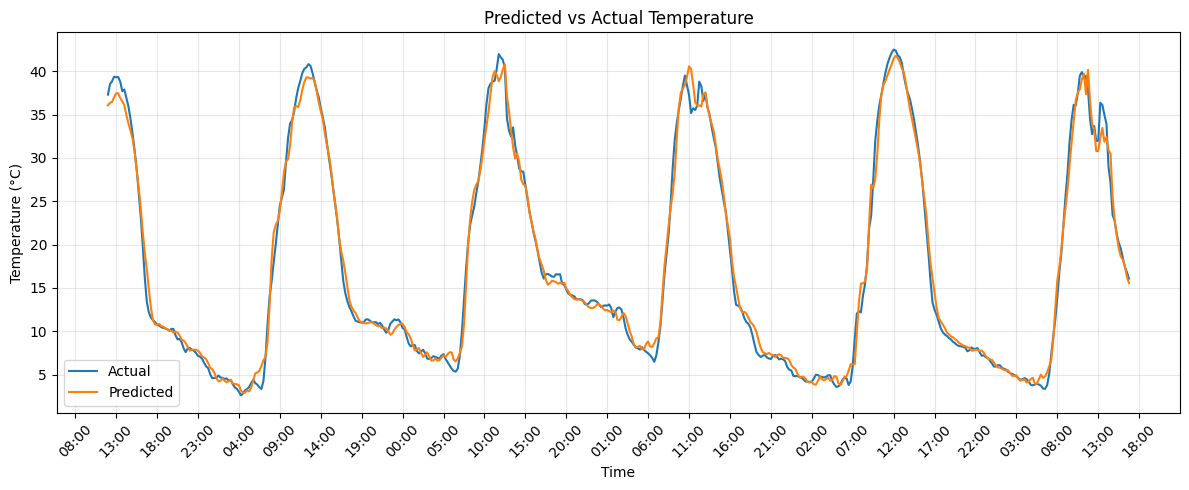

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(new_index[:500], y_new_true[:500], label='Actual')
plt.plot(new_index[:500], y_new_pred[:500], label='Predicted')


plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=5))   # every 2 hours
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.xticks(rotation=45)

plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.title('Predicted vs Actual Temperature')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Plot Predicted vs Actual – Zoomed View

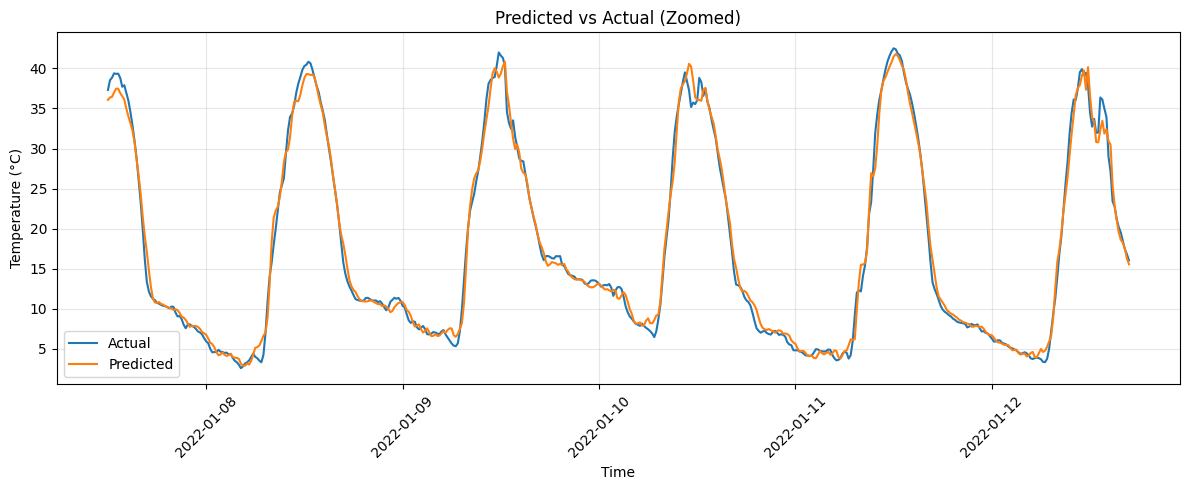

In [ ]:
start = 0
end = 500

plt.figure(figsize=(12,5))
plt.plot(new_index[start:end], y_new_true[start:end], label='Actual')
plt.plot(new_index[start:end], y_new_pred[start:end], label='Predicted')

plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.title('Predicted vs Actual (Zoomed)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Plot Predicted vs Actual – Downsampled Full Year

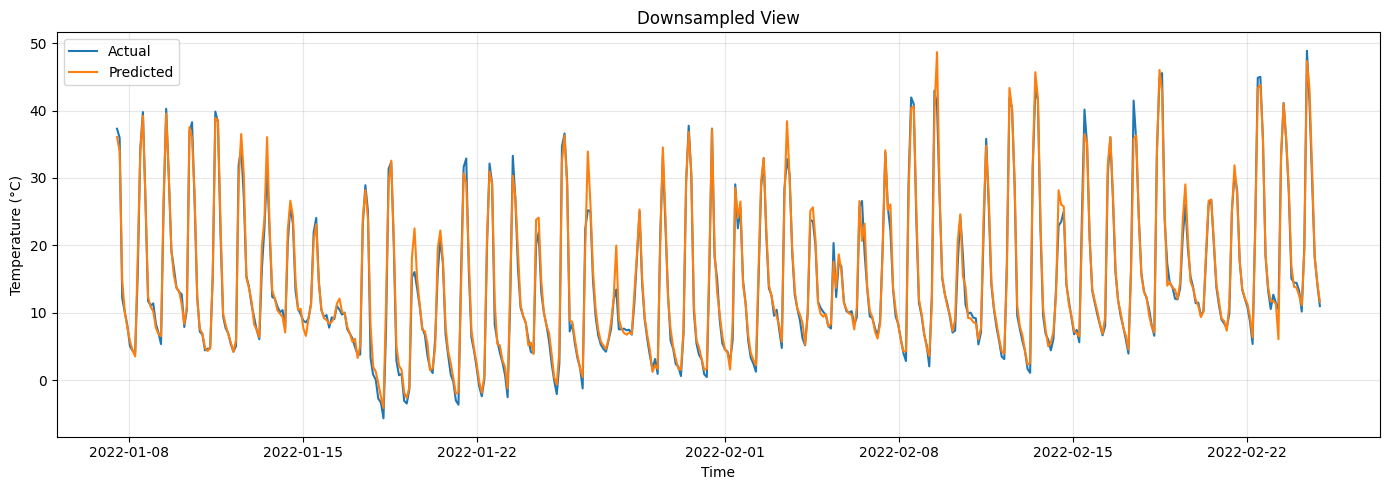

In [ ]:
step = 10 #down sampled

plt.figure(figsize=(14,5))
plt.plot(new_index[::step], y_new_true[::step], label='Actual')
plt.plot(new_index[::step], y_new_pred[::step], label='Predicted')

plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.title('Downsampled View')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 18. Save 2022 Predictions

In [ ]:
# Create DataFrame
results_new_df = pd.DataFrame({
    'datetime': new_index,
    'actual_temperature': y_new_true,
    'predicted_temperature': y_new_pred
}).set_index('datetime')

# Save
results_new_df.to_csv('lstm_temperature_predictions_2022_data_droup02.csv')

print('Predictions saved')
print(results_new_df.head())

Predictions saved
                     actual_temperature  predicted_temperature
datetime                                                      
2022-01-07 12:00:00           37.304667              36.065651
2022-01-07 12:15:00           38.512667              36.372715
2022-01-07 12:30:00           38.839333              36.445602
2022-01-07 12:45:00           39.372667              37.010601
2022-01-07 13:00:00           39.310000              37.457912


# 19. Recursive 1-Year Temperature Forecast

In [ ]:
# =========================================================
# Temperature Recursive Forecast (WITH PROGRESS PRINTS)
# =========================================================

required_objects = ["df", "FEATURE_COLS", "scaler_X", "scaler_y"]
missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise NameError("Missing: " + ", ".join(missing_objects))

# Model selection
if "model" in globals():
    model_for_forecast = model
elif "best_model_lstm" in globals():
    model_for_forecast = best_model_lstm
else:
    raise NameError("Model not found")

SEQ_LEN = 48
N_STEPS = 365 * 24 * 4  # 1 year (15-min intervals)

history_df = df.copy().sort_index()
last_time = history_df.index[-1]

future_dates = []
future_predictions = []

print("🚀 Starting recursive temperature forecast...")

# ---------------------------------------------------------
# Recursive loop
# ---------------------------------------------------------
for step in range(N_STEPS):

    last_window = history_df[FEATURE_COLS].iloc[-SEQ_LEN:]

    X_window_sc = scaler_X.transform(last_window)
    X_window_sc = X_window_sc.reshape(1, SEQ_LEN, len(FEATURE_COLS))

    pred_sc = model_for_forecast.predict(X_window_sc, verbose=0)
    pred_value = scaler_y.inverse_transform(pred_sc)[0, 0]

    next_time = last_time + pd.Timedelta(minutes=15)

    new_row = {}

    # -----------------------------
    # Update lag features
    # -----------------------------
    new_row['temp_lag1'] = pred_value

    if len(history_df) >= 4:
        new_row['temp_lag4'] = history_df['avg_module_temp'].iloc[-4]
    else:
        new_row['temp_lag4'] = pred_value

    if len(history_df) >= 96:
        new_row['temp_lag96'] = history_df['avg_module_temp'].iloc[-96]
    else:
        new_row['temp_lag96'] = pred_value

    # -----------------------------
    # Unknown future features (persistence)
    # -----------------------------
    new_row['irradiance_avg'] = history_df['irradiance_avg'].iloc[-1]
    new_row['wind_speed'] = history_df['wind_speed'].iloc[-1]
    new_row['temp_2m'] = history_df['temp_2m'].iloc[-1]

    # -----------------------------
    # Time features
    # -----------------------------
    new_row["hour_sin"] = np.sin(2 * np.pi * next_time.hour / 24)
    new_row["hour_cos"] = np.cos(2 * np.pi * next_time.hour / 24)
    new_row["month_sin"] = np.sin(2 * np.pi * next_time.month / 12)
    new_row["month_cos"] = np.cos(2 * np.pi * next_time.month / 12)
    new_row["minute_sin"] = np.sin(2 * np.pi * next_time.minute / 60)
    new_row["minute_cos"] = np.cos(2 * np.pi * next_time.minute / 60)

    # Add predicted value to history (needed for lag updates)
    new_row_full = new_row.copy()
    new_row_full['avg_module_temp'] = pred_value

    history_df.loc[next_time] = new_row_full

    future_dates.append(next_time)
    future_predictions.append(pred_value)

    # -----------------------------
    # ✅ PROGRESS PRINT (every 1000 steps)
    # -----------------------------
    if step % 1000 == 0:
        progress = (step / N_STEPS) * 100
        print(f"Progress: {progress:.2f}% | Step {step}/{N_STEPS} | Time: {next_time} | Temp: {pred_value:.2f}")

    last_time = next_time

print("✅ Forecast complete.")

# ---------------------------------------------------------
# Save CSV
# ---------------------------------------------------------
forecast_df = pd.DataFrame({
    "datetime": future_dates,
    "forecasted_module_temp": future_predictions
}).set_index("datetime")

CSV_NAME = "recursive_1year_temperature_forecast.csv"
forecast_df.to_csv(CSV_NAME)

print(f"✅ Saved: {CSV_NAME}")
print(f"✅ Rows: {len(forecast_df):,}")

🚀 Starting recursive temperature forecast...
Progress: 0.00% | Step 0/35040 | Time: 2022-02-25 00:00:00 | Temp: 9.32
Progress: 2.85% | Step 1000/35040 | Time: 2022-03-07 10:00:00 | Temp: 9.29
Progress: 5.71% | Step 2000/35040 | Time: 2022-03-17 20:00:00 | Temp: 10.44
Progress: 8.56% | Step 3000/35040 | Time: 2022-03-28 06:00:00 | Temp: 6.36
Progress: 11.42% | Step 4000/35040 | Time: 2022-04-07 16:00:00 | Temp: 16.38
Progress: 14.27% | Step 5000/35040 | Time: 2022-04-18 02:00:00 | Temp: 5.88
Progress: 17.12% | Step 6000/35040 | Time: 2022-04-28 12:00:00 | Temp: 21.24
Progress: 19.98% | Step 7000/35040 | Time: 2022-05-08 22:00:00 | Temp: 9.66
Progress: 22.83% | Step 8000/35040 | Time: 2022-05-19 08:00:00 | Temp: 17.93
Progress: 25.68% | Step 9000/35040 | Time: 2022-05-29 18:00:00 | Temp: 13.16
Progress: 28.54% | Step 10000/35040 | Time: 2022-06-09 04:00:00 | Temp: 6.31
Progress: 31.39% | Step 11000/35040 | Time: 2022-06-19 14:00:00 | Temp: 19.71
Progress: 34.25% | Step 12000/35040 | Time

## Reload and Preview the Saved Forecast

In [ ]:
ok=pd.read_csv("/content/recursive_1year_temperature_forecast.csv")
ok

,datetime,forecasted_module_temp
0,2022-02-25 00:00:00,9.315074
1,2022-02-25 00:15:00,9.046387
2,2022-02-25 00:30:00,8.831745
3,2022-02-25 00:45:00,8.600687
4,2022-02-25 01:00:00,8.198223
...,...,...
35035,2023-02-24 22:45:00,8.116404
35036,2023-02-24 23:00:00,7.849379
35037,2023-02-24 23:15:00,7.636987
35038,2023-02-24 23:30:00,7.565742


 ## Monthly Seasonality of Forecasted Temperature

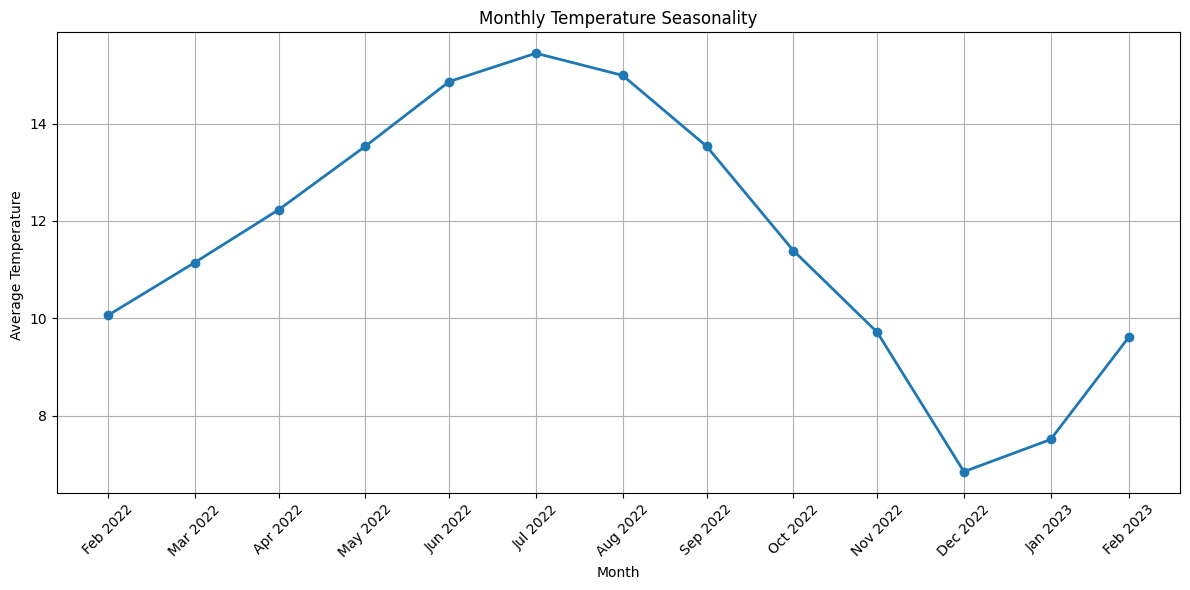

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd



# =========================
# RESAMPLE TO MONTHLY (mean per month)
# =========================
monthly = forecast_df["forecasted_module_temp"].resample('M').mean()

# =========================
# PLOT
# =========================
plt.figure(figsize=(12,6))

plt.plot(
    monthly.index,
    monthly.values,
    linewidth=2,
    marker='o'
)

# Format x-axis as: Jan 2022, Feb 2022, ...
plt.xticks(
    monthly.index,
    monthly.index.strftime('%b %Y'),
    rotation=45
)

plt.title("Monthly Temperature Seasonality")
plt.xlabel("Month")
plt.ylabel("Average Temperature ")
plt.grid(True)

plt.tight_layout()
plt.show()